# Lab 2 – Concolic Results Analysis

Analyses results from `run_concolic_lab.sh`.


In [3]:
import re
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = {'random': '#2196F3', 'smart': '#F44336', 'concolic': '#4CAF50'}
LINESTYLES = {'random': '-', 'smart': '--', 'concolic': '-.'}

In [4]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Adjust RESULTS_ROOT if you run the notebook from a different working directory.
RESULTS_ROOT = Path('..')
FIGURES_DIR  = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

PROBLEMS = [11, 12, 13, 14, 15, 17]
MODES    = ['random', 'smart', 'concolic']

print('Results root:', RESULTS_ROOT.resolve())
print('Figures dir :', FIGURES_DIR.resolve())


Results root: /home/str/JavaInstrumentation
Figures dir : /home/str/JavaInstrumentation/analysis/figures


## 1 – Load data

In [16]:
from typing import Optional

# ── Log parsing ───────────────────────────────────────────────────────────────

def parse_log(path: Path) -> dict:
    result = {
        'total_branches': None,
        'best_run_branches': None,
        'best_trace': None,
        'num_errors': None,
        'error_codes': [],
    }
    if not path.exists():
        return result
    text = path.read_text()
    m = re.search(r'Total unique branches visited: (\d+)', text)
    if m: result['total_branches'] = int(m.group(1))
    m = re.search(r'Max unique branches in a single trace: (\d+)', text)
    if m: result['best_run_branches'] = int(m.group(1))
    m = re.search(r'Best trace: (\[.*?\])', text)
    if m: result['best_trace'] = m.group(1)
    m = re.search(r'Triggered errors \((\d+)\): (\[.*?\])', text)
    if m:
        result['num_errors'] = int(m.group(1))
        codes = re.findall(r'error_\d+', m.group(2))
        result['error_codes'] = sorted(codes, key=lambda x: int(x.split('_')[1]))
    return result


# ── CSV loading ───────────────────────────────────────────────────────────────

def load_branches_csv(problem, mode):
    if mode == "concolic":
        path = RESULTS_ROOT / "concolic_results" / f"problem{problem}_concolic_branches.csv"
    else:
        path = RESULTS_ROOT / "fuzzing_results" / mode / f"problem{problem}_{mode}_branches.csv"

    if not path.exists():
        return None

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df


def load_errors_csv(problem, mode):
    if mode == "concolic":
        path = RESULTS_ROOT / "concolic_results" / f"problem{problem}_concolic_errors.csv"
    else:
        path = RESULTS_ROOT / "fuzzing_results" / mode / f"problem{problem}_{mode}_errors.csv"

    if not path.exists():
        return None

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.sort_values('elapsed_seconds').reset_index(drop=True)
    df['cumulative_errors'] = range(1, len(df) + 1)
    return df


# ── Build master data structures ──────────────────────────────────────────────

logs = {}
branches = {}
errors = {}

for mode in MODES:
    for p in PROBLEMS:
        if mode == "concolic":
            log_path = RESULTS_ROOT / "concolic_results" / f"problem{p}.log"
        else:
            log_path = RESULTS_ROOT / "fuzzing_results" / mode / f"problem{p}.log"

        logs[(p, mode)] = parse_log(log_path)
        branches[(p, mode)] = load_branches_csv(p, mode)
        errors[(p, mode)] = load_errors_csv(p, mode)

available = [(p, m) for (p, m) in logs if logs[(p, m)]['total_branches'] is not None]

print(f'Loaded results for {len(available)} (problem, mode) pairs:')
for p, m in sorted(available):
    print(
        f'  Problem {p:2d} [{m:6s}]  '
        f'branches={logs[(p,m)]["total_branches"]}  '
        f'errors={logs[(p,m)]["num_errors"]}  '
        f'branch_csv={branches[(p,m)] is not None}  '
        f'error_csv={errors[(p,m)] is not None}'
    )

Loaded results for 18 (problem, mode) pairs:
  Problem 11 [concolic]  branches=306  errors=18  branch_csv=True  error_csv=True
  Problem 11 [random]  branches=305  errors=18  branch_csv=True  error_csv=True
  Problem 11 [smart ]  branches=306  errors=18  branch_csv=True  error_csv=True
  Problem 12 [concolic]  branches=209  errors=0  branch_csv=True  error_csv=True
  Problem 12 [random]  branches=225  errors=0  branch_csv=True  error_csv=True
  Problem 12 [smart ]  branches=249  errors=0  branch_csv=True  error_csv=True
  Problem 13 [concolic]  branches=335  errors=14  branch_csv=True  error_csv=True
  Problem 13 [random]  branches=403  errors=22  branch_csv=True  error_csv=True
  Problem 13 [smart ]  branches=402  errors=22  branch_csv=True  error_csv=True
  Problem 14 [concolic]  branches=250  errors=6  branch_csv=True  error_csv=True
  Problem 14 [random]  branches=259  errors=6  branch_csv=True  error_csv=True
  Problem 14 [smart ]  branches=275  errors=5  branch_csv=True  error_cs

## 2 – Summary statistics

In [17]:
rows = []
for p in PROBLEMS:
    for mode in MODES:
        d = logs[(p, mode)]
        rows.append({
            'Problem':            f'Problem {p}',
            'Mode':               mode,
            'Total branches':     d['total_branches'],
            'Best single run':    d['best_run_branches'],
            '# Errors triggered': d['num_errors'],
            'Error codes':        ', '.join(d['error_codes']) if d['error_codes'] else '—',
        })

summary = pd.DataFrame(rows)
summary_pivot = summary.pivot(index='Problem', columns='Mode',
                               values=['Total branches', 'Best single run', '# Errors triggered'])

pd.set_option('display.max_colwidth', 60)
display(summary_pivot)

Total branches              Best single run               \
Mode             concolic random smart        concolic random smart   
Problem                                                               
Problem 11            306    305   306             129    172   165   
Problem 12            209    225   249             116    173   180   
Problem 13            335    403   402             126    192   192   
Problem 14            250    259   275             124    199   211   
Problem 15            555   1833  1836             157    234   254   
Problem 17            958   2370  2287             166    257   257   

           # Errors triggered               
Mode                 concolic random smart  
Problem                                     
Problem 11                 18     18    18  
Problem 12                  0      0     0  
Problem 13                 14     22    22  
Problem 14                  6      6     5  
Problem 15                  0     15    21  
Problem 17                 27     30    30

In [19]:
# Δ improvement table
delta_rows = []

for p in PROBLEMS:
    r = logs[(p, 'random')]
    s = logs[(p, 'smart')]
    c = logs[(p, 'concolic')]

    def delta(a, b):
        if a is None or b is None:
            return None
        return f'{b - a:+d} ({(b - a) / a * 100:+.1f}%)' if a != 0 else f'{b - a:+d}'

    delta_rows.append({
        'Problem': f'Problem {p}',
        'Smart − Random (branches)': delta(r['total_branches'], s['total_branches']),
        'Concolic − Random (branches)': delta(r['total_branches'], c['total_branches']),
        'Concolic − Smart (branches)': delta(s['total_branches'], c['total_branches']),

        'Smart − Random (best run)': delta(r['best_run_branches'], s['best_run_branches']),
        'Concolic − Random (best run)': delta(r['best_run_branches'], c['best_run_branches']),
        'Concolic − Smart (best run)': delta(s['best_run_branches'], c['best_run_branches']),

        'Smart − Random (errors)': delta(r['num_errors'], s['num_errors']),
        'Concolic − Random (errors)': delta(r['num_errors'], c['num_errors']),
        'Concolic − Smart (errors)': delta(s['num_errors'], c['num_errors']),
    })

print('Improvement comparison (pairwise deltas):')
display(pd.DataFrame(delta_rows).set_index('Problem'))

Improvement comparison (pairwise deltas):


,Smart − Random (branches),Concolic − Random (branches),Concolic − Smart (branches),Smart − Random (best run),Concolic − Random (best run),Concolic − Smart (best run),Smart − Random (errors),Concolic − Random (errors),Concolic − Smart (errors)
Problem,,,,,,,,,
Problem 11,+1 (+0.3%),+1 (+0.3%),+0 (+0.0%),-7 (-4.1%),-43 (-25.0%),-36 (-21.8%),+0 (+0.0%),+0 (+0.0%),+0 (+0.0%)
Problem 12,+24 (+10.7%),-16 (-7.1%),-40 (-16.1%),+7 (+4.0%),-57 (-32.9%),-64 (-35.6%),+0,+0,+0
Problem 13,-1 (-0.2%),-68 (-16.9%),-67 (-16.7%),+0 (+0.0%),-66 (-34.4%),-66 (-34.4%),+0 (+0.0%),-8 (-36.4%),-8 (-36.4%)
Problem 14,+16 (+6.2%),-9 (-3.5%),-25 (-9.1%),+12 (+6.0%),-75 (-37.7%),-87 (-41.2%),-1 (-16.7%),+0 (+0.0%),+1 (+20.0%)
Problem 15,+3 (+0.2%),-1278 (-69.7%),-1281 (-69.8%),+20 (+8.5%),-77 (-32.9%),-97 (-38.2%),+6 (+40.0%),-15 (-100.0%),-21 (-100.0%)
Problem 17,-83 (-3.5%),-1412 (-59.6%),-1329 (-58.1%),+0 (+0.0%),-91 (-35.4%),-91 (-35.4%),+0 (+0.0%),-3 (-10.0%),-3 (-10.0%)


## 3 – Branch coverage convergence

Each subplot shows how the total number of **unique branches** discovered grows over time for one problem.
Sampled every 5 seconds during the run.

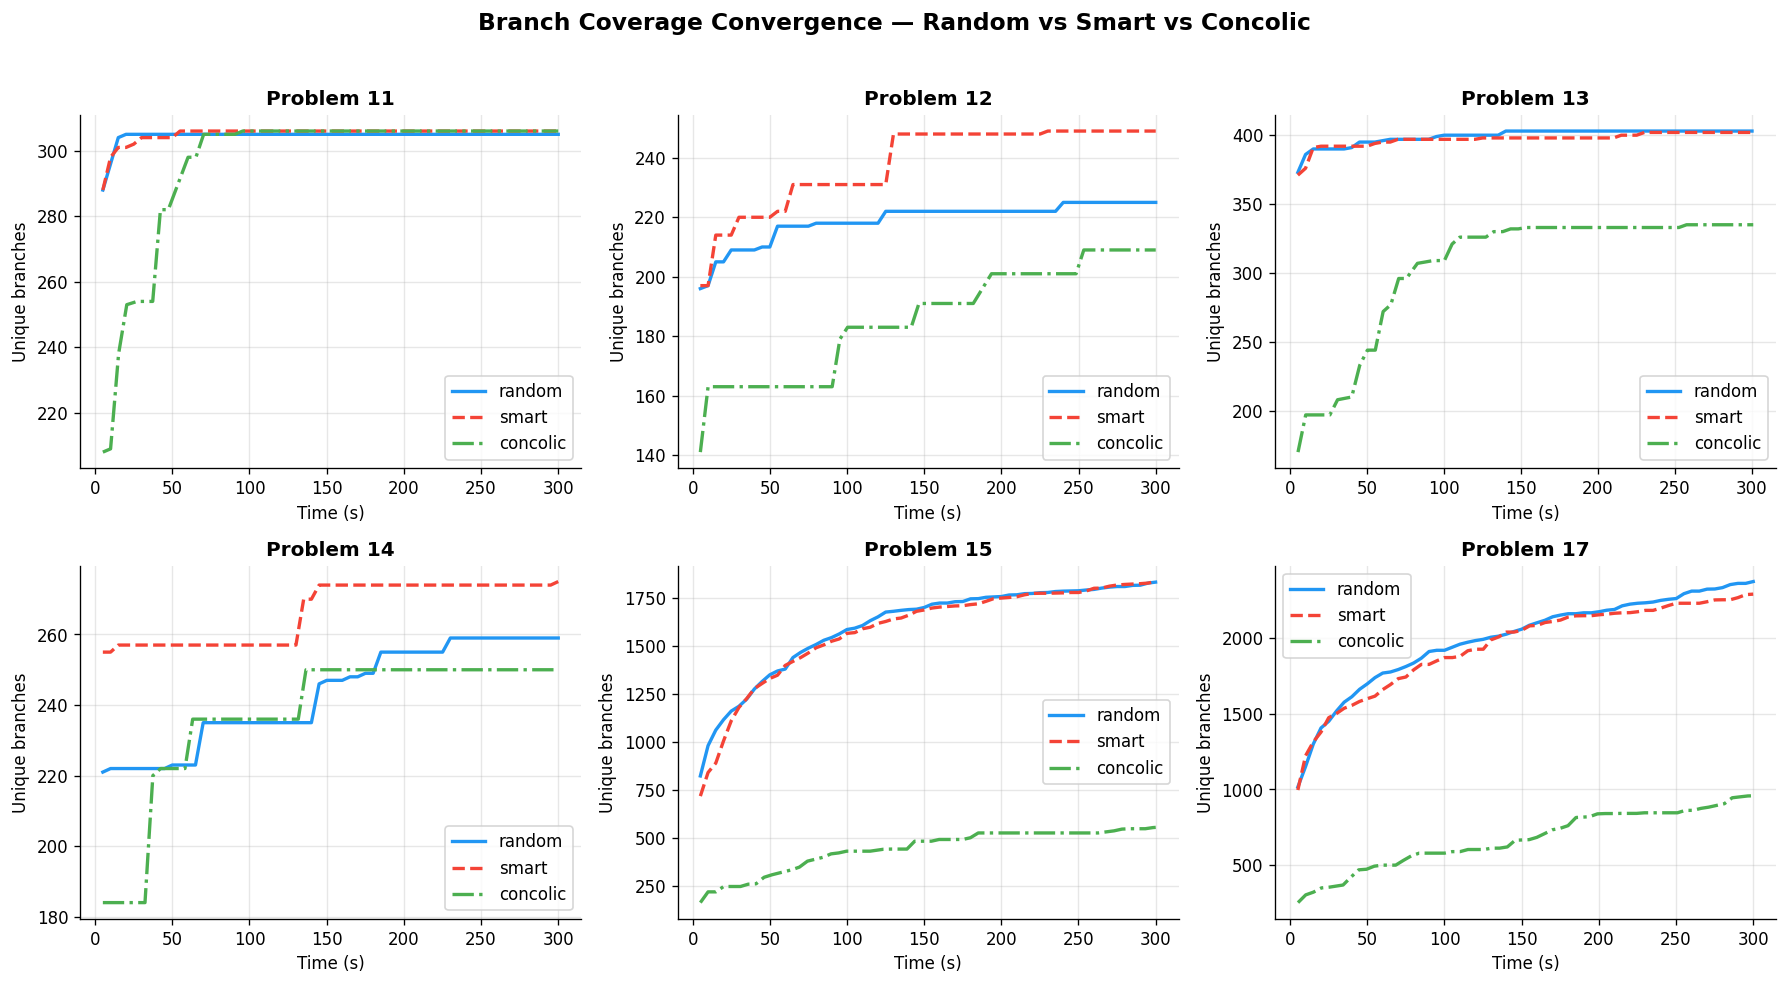

Saved: figures/concolic_branch_convergence.png


In [22]:
ncols = 3
nrows = (len(PROBLEMS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, p in enumerate(PROBLEMS):
    ax = axes[idx]
    has_data = False
    for mode in MODES:
        df = branches[(p, mode)]
        if df is not None and not df.empty:
            ax.plot(df['elapsed_seconds'], df['unique_branches'],
                    color=COLORS[mode], ls=LINESTYLES[mode],
                    linewidth=2, label=mode)
            has_data = True
    ax.set_title(f'Problem {p}', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Unique branches')
    ax.legend()
    if not has_data:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes,
                color='grey')

for idx in range(len(PROBLEMS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Branch Coverage Convergence — Random vs Smart vs Concolic',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()

FIGURES_DIR.mkdir(exist_ok=True)

fig.savefig(FIGURES_DIR / 'concolic_branch_convergence.png', bbox_inches='tight')

plt.show()

print('Saved: figures/concolic_branch_convergence.png')

## 4 – Error discovery convergence

Each subplot shows the **cumulative number of unique error codes** triggered over time.
Each step represents the first time a new error code was reached.

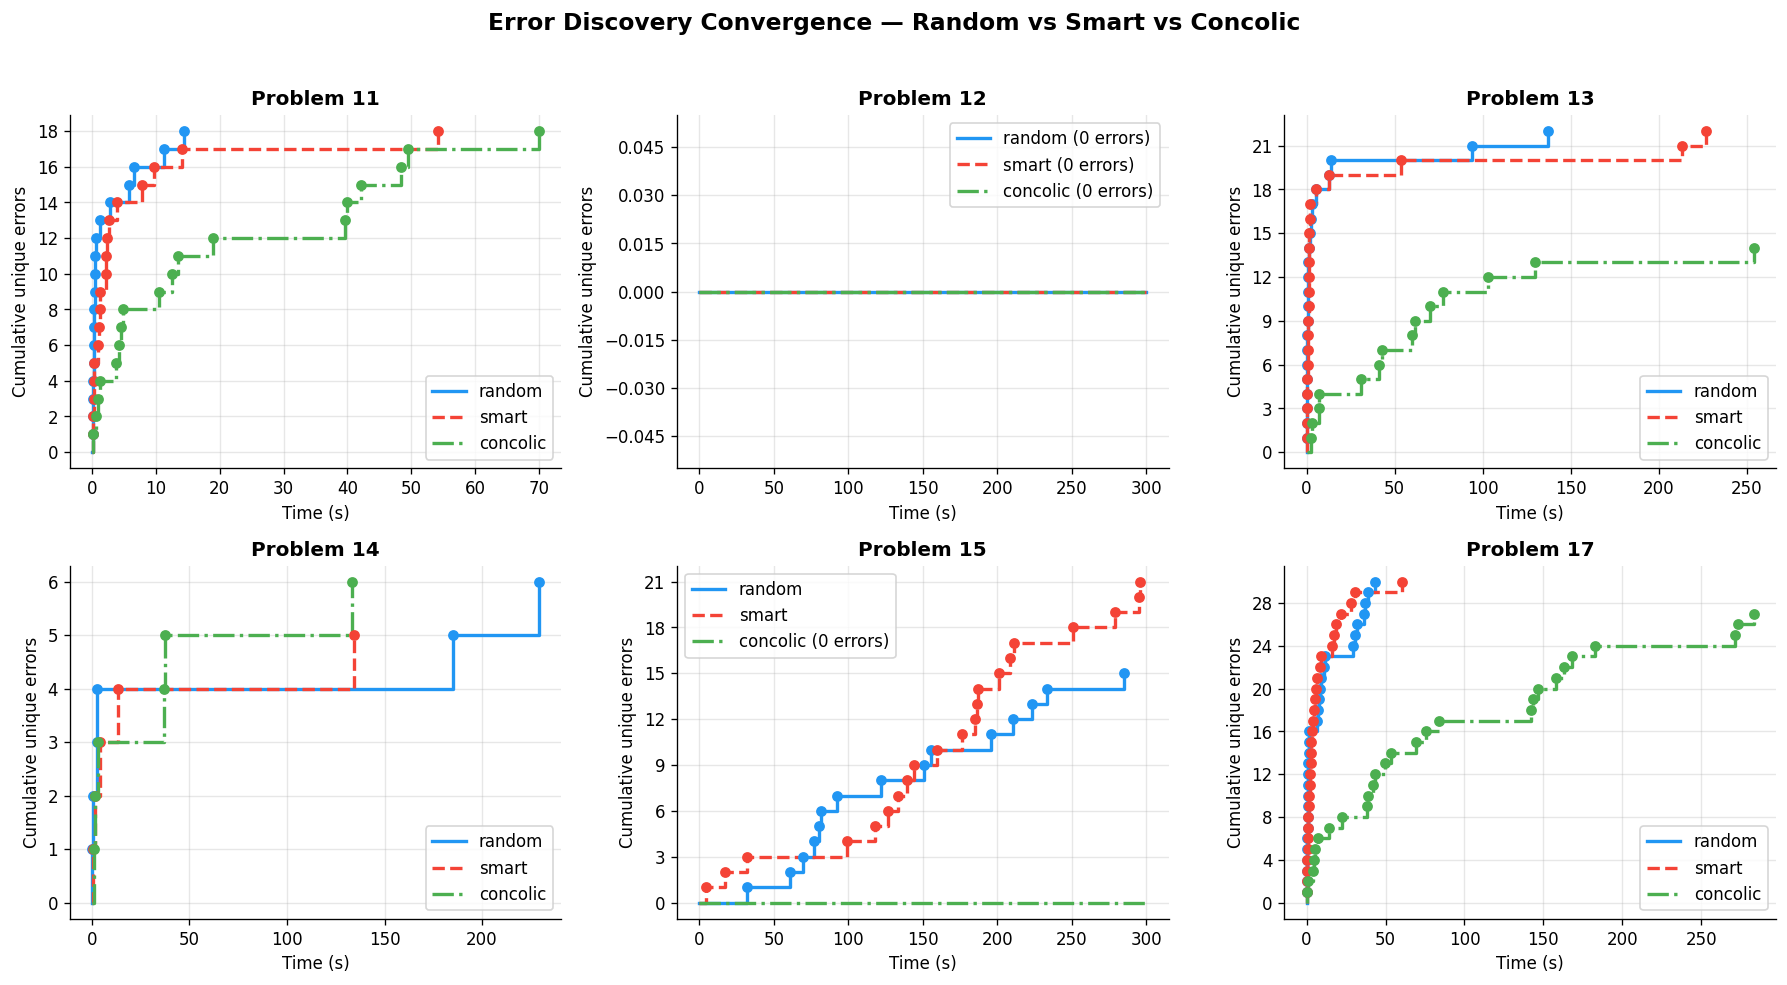

Saved: figures/concolic_error_convergence.png


In [21]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, p in enumerate(PROBLEMS):
    ax = axes[idx]
    has_data = False
    for mode in MODES:
        df = errors[(p, mode)]
        # Build step-function: prepend (0, 0) so graph starts at origin
        if df is not None and not df.empty:
            t = [0.0] + list(df['elapsed_seconds'])
            c = [0]   + list(df['cumulative_errors'])
            ax.step(t, c, where='post',
                    color=COLORS[mode], ls=LINESTYLES[mode],
                    linewidth=2, label=mode)
            # Mark each discovery event
            ax.scatter(df['elapsed_seconds'], df['cumulative_errors'],
                       color=COLORS[mode], s=30, zorder=5)
            has_data = True
        elif logs[(p, mode)]['num_errors'] == 0:
            # Flat line at zero
            ax.plot([0, 300], [0, 0],
                    color=COLORS[mode], ls=LINESTYLES[mode],
                    linewidth=2, label=f'{mode} (0 errors)')
            has_data = True
    ax.set_title(f'Problem {p}', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cumulative unique errors')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend()
    if not has_data:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes,
                color='grey')

for idx in range(len(PROBLEMS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Error Discovery Convergence — Random vs Smart vs Concolic',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()

FIGURES_DIR.mkdir(exist_ok=True)
fig.savefig(FIGURES_DIR / 'concolic_error_convergence.png', bbox_inches='tight')
plt.show()
print('Saved: figures/concolic_error_convergence.png')

## 5 – Aggregate comparison bar charts

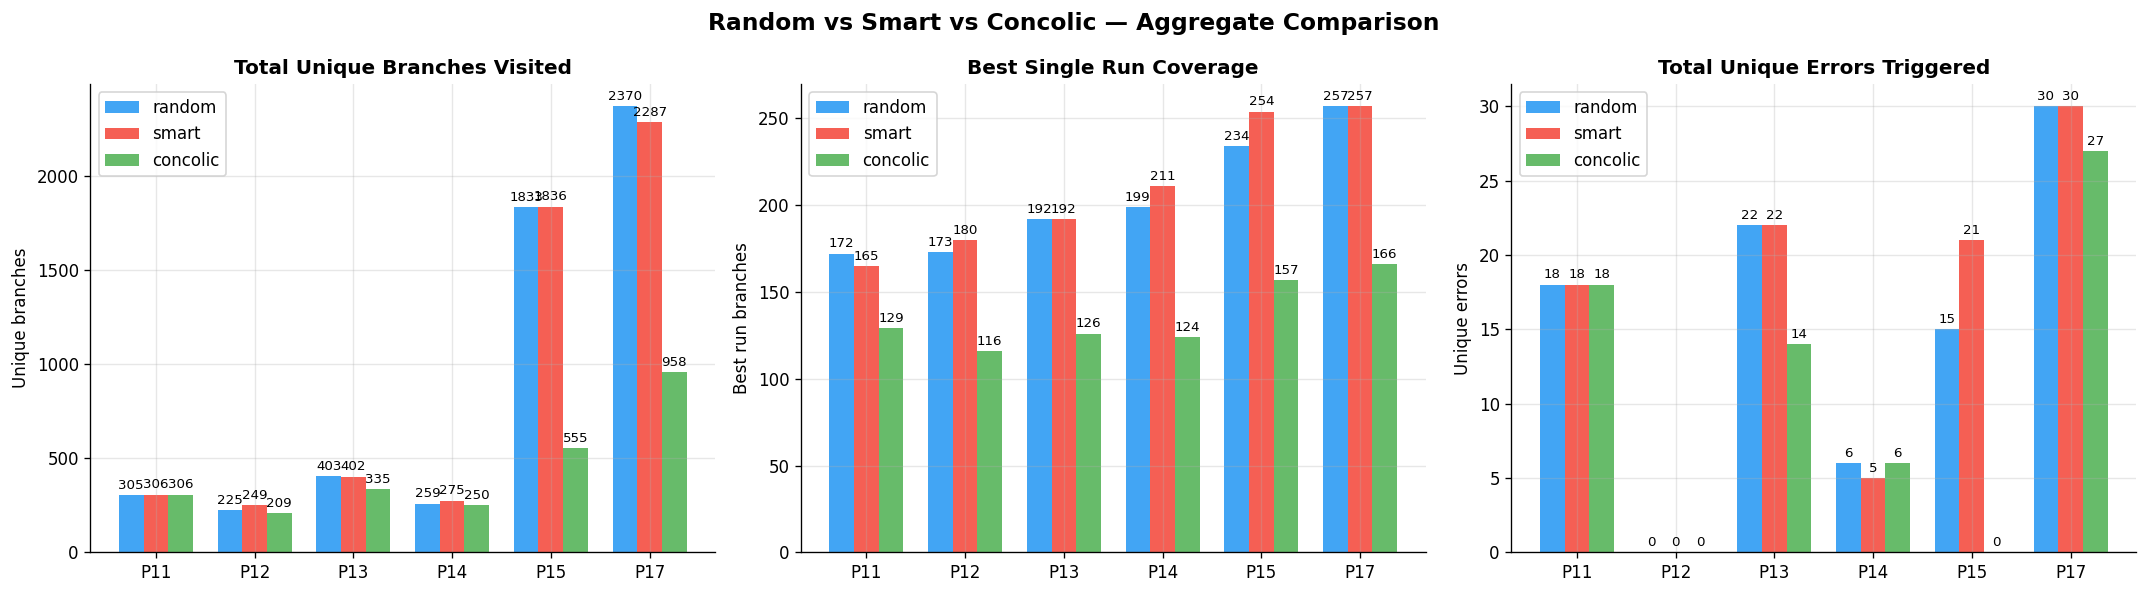

Saved: figures/concolic_aggregate_comparison.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x        = np.arange(len(PROBLEMS))
width    = 0.25
labels   = [f'P{p}' for p in PROBLEMS]

for ax, metric, ylabel, title in [
    (axes[0], 'total_branches',  'Unique branches',  'Total Unique Branches Visited'),
    (axes[1], 'best_run_branches','Best run branches','Best Single Run Coverage'),
    (axes[2], 'num_errors',      'Unique errors',    'Total Unique Errors Triggered'),
]:
    for i, mode in enumerate(MODES):
        vals = [logs[(p, mode)][metric] or 0 for p in PROBLEMS]
        bars = ax.bar(x + (i - 1) * width, vals, width,
                      label=mode, color=COLORS[mode], alpha=0.85)
        ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()

fig.suptitle('Random vs Smart vs Concolic — Aggregate Comparison', fontsize=14, fontweight='bold')
fig.tight_layout()

FIGURES_DIR.mkdir(exist_ok=True)

fig.savefig(FIGURES_DIR / 'concolic_aggregate_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: figures/concolic_aggregate_comparison.png')

## 6 – Error code detail

Which specific error codes each fuzzer found, and which are exclusive to one mode.

In [24]:
for p in PROBLEMS:
    r_codes = set(logs[(p, 'random')]['error_codes'])
    s_codes = set(logs[(p, 'smart')]['error_codes'])
    c_codes = set(logs[(p, 'concolic')]['error_codes'])

    both_rs = r_codes & s_codes
    r_only = r_codes - s_codes - c_codes
    s_only = s_codes - r_codes - c_codes
    c_only = c_codes - r_codes - s_codes

    print(f'Problem {p}')
    print(f'  random  ({len(r_codes):2d}): {sorted(r_codes, key=lambda x: int(x.split("_")[1])) or "—"}')
    print(f'  smart   ({len(s_codes):2d}): {sorted(s_codes, key=lambda x: int(x.split("_")[1])) or "—"}')
    print(f'  concolic({len(c_codes):2d}): {sorted(c_codes, key=lambda x: int(x.split("_")[1])) or "—"}')

    if r_only: print(f'  random-only   : {sorted(r_only, key=lambda x: int(x.split("_")[1]))}')
    if s_only: print(f'  smart-only    : {sorted(s_only, key=lambda x: int(x.split("_")[1]))}')
    if c_only: print(f'  concolic-only : {sorted(c_only, key=lambda x: int(x.split("_")[1]))}')
    if both_rs: print(f'  shared R/S    : {sorted(both_rs, key=lambda x: int(x.split("_")[1]))}')
    print()

Problem 11
  random  (18): ['error_0', 'error_9', 'error_13', 'error_24', 'error_26', 'error_39', 'error_42', 'error_48', 'error_52', 'error_60', 'error_62', 'error_74', 'error_75', 'error_82', 'error_91', 'error_93', 'error_94', 'error_95']
  smart   (18): ['error_0', 'error_9', 'error_13', 'error_24', 'error_26', 'error_39', 'error_42', 'error_48', 'error_52', 'error_60', 'error_62', 'error_74', 'error_75', 'error_82', 'error_91', 'error_93', 'error_94', 'error_95']
  concolic(18): ['error_0', 'error_9', 'error_13', 'error_24', 'error_26', 'error_39', 'error_42', 'error_48', 'error_52', 'error_60', 'error_62', 'error_74', 'error_75', 'error_82', 'error_91', 'error_93', 'error_94', 'error_95']
  shared R/S    : ['error_0', 'error_9', 'error_13', 'error_24', 'error_26', 'error_39', 'error_42', 'error_48', 'error_52', 'error_60', 'error_62', 'error_74', 'error_75', 'error_82', 'error_91', 'error_93', 'error_94', 'error_95']

Problem 12
  random  ( 0): —
  smart   ( 0): —
  concolic( 0):

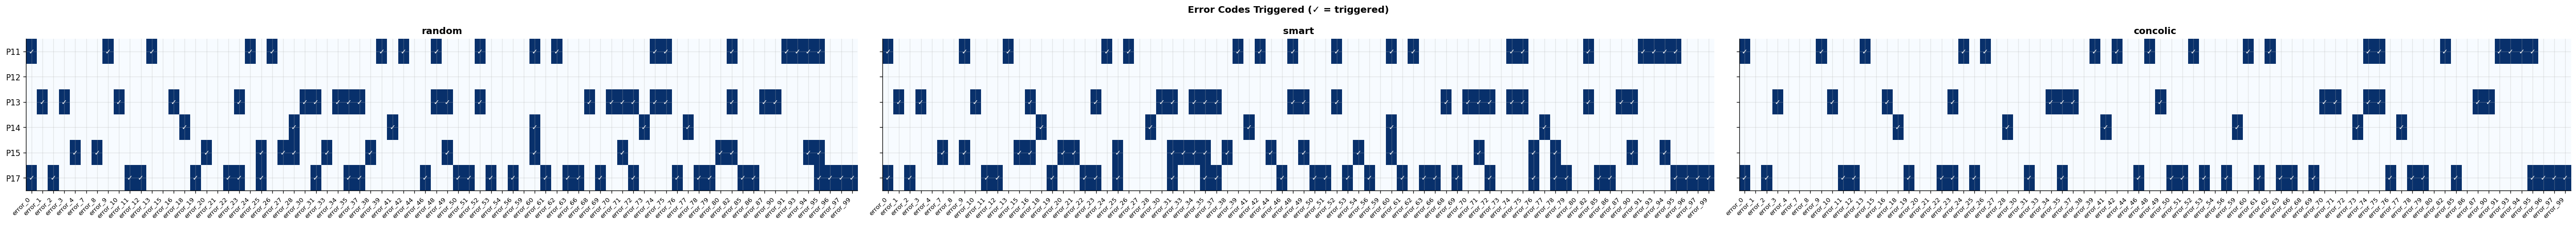

Saved: figures/concolic_error_heatmap.png


In [25]:
# Heatmap: which errors were triggered per problem per mode
# Collect all error codes across all problems and modes
all_codes = sorted(
    {c for p in PROBLEMS for m in MODES for c in logs[(p, m)]['error_codes']},
    key=lambda x: int(x.split('_')[1])
)

if all_codes:
    fig, axes = plt.subplots(1, len(MODES), figsize=(max(8, len(all_codes) * 0.6), 4), sharey=True)
    if len(MODES) == 1:
        axes = [axes]

    for ax, mode in zip(axes, MODES):
        matrix = pd.DataFrame(
            [[1 if c in logs[(p, mode)]['error_codes'] else 0
              for c in all_codes]
             for p in PROBLEMS],
            index=[f'P{p}' for p in PROBLEMS],
            columns=all_codes
        )
        im = ax.imshow(matrix.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(len(all_codes)))
        ax.set_xticklabels(all_codes, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(PROBLEMS)))
        ax.set_yticklabels([f'P{p}' for p in PROBLEMS])
        ax.set_title(f'{mode}', fontweight='bold')
        # Annotate cells
        for i in range(len(PROBLEMS)):
            for j in range(len(all_codes)):
                if matrix.values[i, j]:
                    ax.text(j, i, '✓', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    fig.suptitle('Error Codes Triggered (✓ = triggered)', fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'concolic_error_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Saved: figures/concolic_error_heatmap.png')
else:
    print('No error codes found in any result — skipping heatmap.')

## 7 – Best trace per problem

In [26]:
rows = []
for p in PROBLEMS:
    for mode in MODES:
        rows.append({
            'Problem': f'Problem {p}',
            'Mode':    mode,
            'Best run (branches)': logs[(p, mode)]['best_run_branches'],
            'Best trace': logs[(p, mode)]['best_trace'] or '—',
        })
display(pd.DataFrame(rows))

,Problem,Mode,Best run (branches),Best trace
0,Problem 11,random,172,"[F, J, E, I, B, F, G, B, E, I]"
1,Problem 11,smart,165,"[F, C, J, E, E, B, E, F, F, G, E]"
2,Problem 11,concolic,129,"[E, E, F, C, E, C, E, A, A, D]"
3,Problem 12,random,173,"[E, G, E, C, F, C, A, F, J, G]"
4,Problem 12,smart,180,"[E, G, D, F, C, J, I, D, E, H, A, D, H]"
5,Problem 12,concolic,116,"[H, I, G, C, H, H, B, A, A, A]"
6,Problem 13,random,192,"[H, G, H, H, G, E, C, D, A, G]"
7,Problem 13,smart,192,"[C, C, D, H, E, I, F, J, E, I, C]"
8,Problem 13,concolic,126,"[J, A, H, J, G, F, J, G, D, I]"
9,Problem 14,random,199,"[N, C, J, K, G, F, D, C, I, M]"


## 8 – Convergence speed: time to first N errors

For each problem that triggered at least one error in both modes, compare how quickly the fuzzers
first found 1, 2, 3, … errors.

In [27]:
for p in PROBLEMS:
    dfs = {m: errors[(p, m)] for m in MODES if errors[(p, m)] is not None and not errors[(p, m)].empty}
    if len(dfs) < 2:
        continue
    max_n = max(len(df) for df in dfs.values())
    if max_n == 0:
        continue
    print(f'Problem {p} — time to reach each successive error:')
    rows = []
    for n in range(1, max_n + 1):
        row = {'N-th error': n}
        for mode, df in dfs.items():
            if n <= len(df):
                row[mode] = f"{df.iloc[n-1]['elapsed_seconds']:.1f}s==({df.iloc[n-1]['error_code']})"
            else:
                row[mode] = '—'
        rows.append(row)
    display(pd.DataFrame(rows).set_index('N-th error'))
    print()

Problem 11 — time to reach each successive error:


,random,smart,concolic
N-th error,,,
1,0.1s==(error_62),0.2s==(error_60),0.1s==(error_95)
2,0.1s==(error_95),0.2s==(error_95),0.7s==(error_60)
3,0.2s==(error_60),0.3s==(error_48),0.9s==(error_74)
4,0.2s==(error_9),0.4s==(error_24),1.2s==(error_82)
5,0.3s==(error_0),0.4s==(error_62),3.7s==(error_62)
6,0.3s==(error_74),0.9s==(error_0),4.2s==(error_0)
7,0.4s==(error_26),1.1s==(error_74),4.5s==(error_93)
8,0.4s==(error_91),1.2s==(error_9),4.8s==(error_75)
9,0.5s==(error_24),1.2s==(error_93),10.5s==(error_48)



Problem 13 — time to reach each successive error:


,random,smart,concolic
N-th error,,,
1,0.0s==(error_34),0.1s==(error_70),2.3s==(error_49)
2,0.1s==(error_35),0.2s==(error_49),3.3s==(error_90)
3,0.2s==(error_3),0.2s==(error_1),7.0s==(error_70)
4,0.3s==(error_70),0.5s==(error_90),7.2s==(error_34)
5,0.3s==(error_49),0.5s==(error_34),31.0s==(error_35)
6,0.4s==(error_48),0.6s==(error_23),41.4s==(error_10)
7,0.4s==(error_75),0.8s==(error_10),43.0s==(error_75)
8,0.5s==(error_71),0.8s==(error_75),59.7s==(error_3)
9,0.6s==(error_90),0.9s==(error_35),61.5s==(error_37)



Problem 14 — time to reach each successive error:


,random,smart,concolic
N-th error,,,
1,0.1s==(error_41),0.4s==(error_41),1.0s==(error_41)
2,0.4s==(error_77),1.4s==(error_77),1.5s==(error_77)
3,2.6s==(error_18),3.9s==(error_18),3.3s==(error_18)
4,2.6s==(error_28),13.4s==(error_28),37.0s==(error_73)
5,184.9s==(error_60),134.6s==(error_60),37.3s==(error_28)
6,229.2s==(error_73),—,133.4s==(error_59)



Problem 15 — time to reach each successive error:


,random,smart
N-th error,,
1,32.0s==(error_33),4.8s==(error_15)
2,60.8s==(error_8),17.6s==(error_38)
3,69.3s==(error_38),32.3s==(error_20)
4,76.7s==(error_25),99.4s==(error_78)
5,80.5s==(error_94),118.1s==(error_34)
6,81.4s==(error_28),126.9s==(error_90)
7,92.5s==(error_27),133.6s==(error_54)
8,121.8s==(error_95),139.1s==(error_7)
9,151.0s==(error_49),144.3s==(error_31)



Problem 17 — time to reach each successive error:


,random,smart,concolic
N-th error,,,
1,0.2s==(error_97),0.1s==(error_22),0.2s==(error_2)
2,0.2s==(error_69),0.2s==(error_96),1.2s==(error_69)
3,0.2s==(error_66),0.4s==(error_53),4.1s==(error_53)
4,0.3s==(error_2),0.5s==(error_2),4.9s==(error_78)
5,0.3s==(error_53),0.9s==(error_99),5.1s==(error_66)
6,0.5s==(error_25),0.9s==(error_78),7.3s==(error_35)
7,0.7s==(error_99),1.0s==(error_66),14.4s==(error_96)
8,0.7s==(error_0),1.2s==(error_69),22.3s==(error_11)
9,0.7s==(error_61),1.4s==(error_51),38.1s==(error_97)
